# Local Composition on Discrete $SE(2)$, $\mathbb{Z}_n^2 \rtimes C_m$

**Speculative idea.** Instead of supervising the network on *all* group products
$g_1 \cdots g_k$ (the standard "global" composition objective), supervise it
only on products built from **small steps near the identity**:

$$
L_{\mathrm{local}}(\Theta) =
\frac{1}{2|G||S|^k}
\sum_{g \in G}\,\sum_{(s_1,\dots,s_k)\in S^k}
\bigl\| x_{g\,s_1\,\cdots\,s_k}\;-\;f(x_g, x_{s_1},\dots,x_{s_k};\Theta) \bigr\|^2,
$$

where $S \subset G$ is a small "generator" set near the identity (the discrete
analogue of $\Xi_\varepsilon \subset \mathfrak{g}$). The headline question this
notebook explores: **does locality generalize?** I.e. does training only on
near-identity products produce a network that solves the *full* composition
task $g_1 \cdots g_k$ for arbitrary $g_t$?

This is a **prototype**: it is fully self-contained in this notebook and does
**not modify any code in `src/`**. The local dataset is built inline; the
existing training loop is reused as-is by passing a *global* `DataLoader` as
the `eval_dataloader`, which causes `train()` to log the global-test loss
under the name `val_loss_history`.

**Group:** $\mathbb{Z}_n^2 \rtimes C_m$ ($n=6$, $m=3$, order $108$).
**Architecture:** `QuadraticRNN`, same as `notebooks/discrete_se2_rnn.ipynb`.


## Imports


In [13]:
import itertools
import os
import random

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.groups import DiscreteSE2Group
import src.dataset as dataset
import src.model as model
import src.template as template
import src.train as train_mod
import src.viz as viz

## Device


In [14]:
device_name = "cuda:0"  # change to "cpu" if no GPU

if device_name.startswith("cuda") and not torch.cuda.is_available():
    print("Warning: CUDA not available, falling back to CPU")
    device = torch.device("cpu")
else:
    device = torch.device(device_name)

print(f"Using device: {device}")

Using device: cuda:0


## Configuration


In [15]:
TEST_MODE = os.environ.get("NOTEBOOK_TEST_MODE", "0") == "1"

seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

n = 6
m = 3  # rotation order: one of {1, 2, 3, 4, 6}
group = DiscreteSE2Group(n=n, m=m)
group_size = group.order

ROTATION_ANGLES = {1: [0], 2: [0, 180], 3: [0, 120, 240], 4: [0, 90, 180, 270], 6: [0, 60, 120, 180, 240, 300]}
angles = ROTATION_ANGLES[m]
group_label = f"Z_{n}^2 ⋊ C_{m}"
group_label_latex = f"$\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_{{{m}}}$"
file_tag = f"discrete_se2_n{n}_m{m}_local"

hidden_dim = 50 if TEST_MODE else 3000
epochs     = 2  if TEST_MODE else 1000
lr         = 1e-3
init_scale = 5e-2

# Sequence length (matches the model's `k`). Default = 2 reproduces L_local
# (one small step from any starting g). Increase to 3 or 4 to study
# L_local-seq (a trajectory of multiple small steps from any starting g).
seq_len = 2

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Group: {group_label}, order {group_size}")
print(f"Irreps: {len(group.irreps())}")
print(f"Sequence length: {seq_len}  (=> {seq_len - 1} small step(s) per sample)")

Group: Z_6^2 ⋊ C_3, order 108
Irreps: 20
Sequence length: 2  (=> 1 small step(s) per sample)


## Template

Same template as `discrete_se2_rnn.ipynb` so the two are directly comparable.


In [16]:
n_irreps = len(group.irreps())
powers = [1.0] * n_irreps
tpl = template.custom_fourier(group, powers)

print(f"Template shape: {tpl.shape}, sum: {tpl.sum():.4f}, max: {tpl.max():.4f}")

Template shape: (108,), sum: 0.0000, max: 3.9452


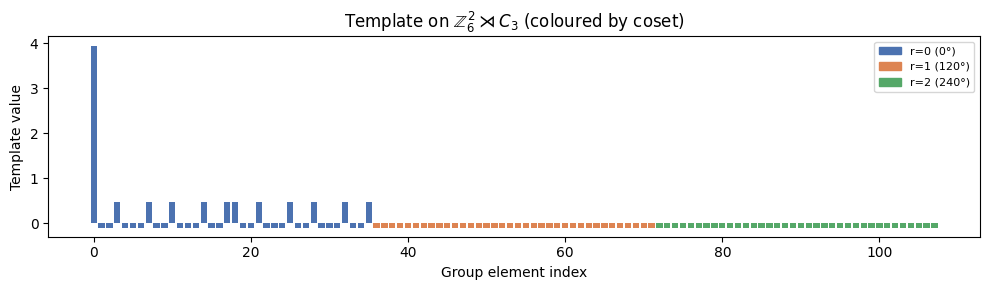

In [17]:
_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
colors = _palette[:m]
coset_labels = [f"r={r} ({angles[r]}°)" for r in range(m)]
bar_colors = [colors[idx // (n * n)] for idx in range(group_size)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(group_size), tpl, color=bar_colors)
ax.set_xlabel("Group element index")
ax.set_ylabel("Template value")
ax.set_title(f"Template on {group_label_latex} (coloured by coset)")

patches = [mpatches.Patch(color=colors[i], label=coset_labels[i]) for i in range(m)]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_template.pdf", bbox_inches="tight")
plt.show()

## Generator set $S$ (the "small steps near the identity")

Discrete analogue of "small Lie-algebra elements". For
$G = \mathbb{Z}_n^2 \rtimes C_m$ the natural choice is the symmetric basis

$$
S = \{(\pm 1, 0, 0),\ (0, \pm 1, 0),\ (0, 0, \pm 1)\},
$$

i.e. unit translations along $x$ and $y$, and unit rotation $\pm 1$. We *exclude* the
identity by default (it makes the corresponding samples trivial).

<!-- This is the **main knob** to play with. Other reasonable choices: -->

- **Forward only:** $\{(1,0,0), (0,1,0), (0,0,1)\}$ &mdash; not closed under inverse.
- **Cayley ball of radius $r$:** all elements reachable from identity in $\le r$ generator steps.
- **Pure translations:** drop the rotation generator.


In [18]:
def make_basis_generators(group, *, include_identity=False, include_inverses=True):
    """Symmetric Lie-basis generator set for DiscreteSE2Group."""
    n_, m_ = group._n, group._m
    gens = set()
    if include_identity:
        gens.add(group._encode(0, 0, 0))
    # Translation generators
    gens.add(group._encode(1, 0, 0))
    gens.add(group._encode(0, 1, 0))
    if include_inverses:
        gens.add(group._encode(n_ - 1, 0, 0))
        gens.add(group._encode(0, n_ - 1, 0))
    # Rotation generator (only nontrivial when m > 1)
    if m_ > 1:
        gens.add(group._encode(0, 0, 1))
        if include_inverses and m_ > 2:
            gens.add(group._encode(0, 0, m_ - 1))
    return sorted(gens)


S = make_basis_generators(group, include_identity=False, include_inverses=True)
print(f"|S| = {len(S)} generators (indices): {S}")
print("Decoded (x, y, r):")
for s in S:
    print(f"  idx={s:3d}  ->  {group._decode(s)}")

|S| = 6 generators (indices): [1, 5, 6, 30, 36, 72]
Decoded (x, y, r):
  idx=  1  ->  (0, 1, 0)
  idx=  5  ->  (0, 5, 0)
  idx=  6  ->  (1, 0, 0)
  idx= 30  ->  (5, 0, 0)
  idx= 36  ->  (0, 0, 1)
  idx= 72  ->  (0, 0, 2)


## Build the local dataset (inline, no `src/` changes)


In [19]:
def build_local_dataset(group, generators, seq_len, template_vec):
    """Local-composition dataset: (g_0, s_1, ..., s_{seq_len-1}).

    The first input ``g_0`` ranges over **all** of ``G``; the remaining
    ``seq_len - 1`` inputs each range over ``generators``. Targets follow
    the same convention as ``GroupCompositionDataset._build_group``: the
    network is asked to predict the template under the cumulative product
    in input order.

    Returns
    -------
    X : torch.Tensor, shape (N, seq_len, |G|)
    Y : torch.Tensor, shape (N, |G|)
    sequence : np.ndarray, shape (N, seq_len), int64
    """
    G = group.order
    S = list(generators)
    n_steps = seq_len - 1
    rep = group.regular_rep()  # (G, G, G)
    template_vec = np.asarray(template_vec).ravel().astype(np.float32)
    assert template_vec.shape == (G,)

    # Enumerate (g_0, s_1, ..., s_{seq_len-1})
    sequences = [
        (g0,) + tuple(steps)
        for g0 in range(G)
        for steps in itertools.product(S, repeat=n_steps)
    ]
    sequence = np.array(sequences, dtype=np.int64)
    N = sequence.shape[0]

    X = np.zeros((N, seq_len, G), dtype=np.float32)
    Y = np.zeros((N, G), dtype=np.float32)
    for i in range(N):
        cum = np.eye(G, dtype=np.float32)
        for t in range(seq_len):
            g_rep = rep[sequence[i, t]]
            X[i, t, :] = g_rep @ template_vec
            cum = g_rep @ cum
        Y[i] = cum @ template_vec

    return torch.from_numpy(X), torch.from_numpy(Y), sequence


X_local, Y_local, seq_local = build_local_dataset(group, S, seq_len, tpl)
print(f"Local dataset: {X_local.shape[0]} samples")
print(f"  X shape: {X_local.shape}  (= |G| * |S|^{seq_len - 1} = {group_size} * {len(S)}^{seq_len - 1})")
print(f"  Y shape: {Y_local.shape}")

X_local = X_local.to(device)
Y_local = Y_local.to(device)
local_ds = TensorDataset(X_local, Y_local)
local_loader = DataLoader(local_ds, batch_size=len(local_ds), shuffle=False)

Local dataset: 648 samples
  X shape: torch.Size([648, 2, 108])  (= |G| * |S|^1 = 108 * 6^1)
  Y shape: torch.Size([648, 108])


## Build the global eval dataset (uses existing `GroupCompositionDataset` unchanged)

Total global pairs are $|G|^{\,\text{seq\_len}}$. For `seq_len = 2` ($108^2 = 11{,}664$)
we use exhaustive enumeration. For `seq_len >= 3` ($108^3 \approx 1.26\text{M}$) the
exhaustive guard at `src/dataset.py` trips, so we fall back to a large random sample.


In [20]:
global_total = group_size ** seq_len
if global_total <= 1_000_000:
    eval_mode = "exhaustive"
    eval_kwargs = {"mode": "exhaustive"}
else:
    eval_mode = "sampled"
    eval_kwargs = {"mode": "sampled", "num_samples": 65_536}

print(f"Global eval mode: {eval_mode}  (|G|^seq_len = {global_total:,})")

global_ds = dataset.GroupCompositionDataset(
    group,
    template=tpl,
    k=seq_len,
    **eval_kwargs,
)
X_global = global_ds.X.to(device)
Y_global = global_ds.Y.to(device)
global_eval_ds = TensorDataset(X_global, Y_global)
# train() pulls a single batch via next(iter(eval_dataloader)) per epoch,
# so put the entire eval set in one batch.
global_eval_loader = DataLoader(global_eval_ds, batch_size=len(global_eval_ds), shuffle=False)
print(f"Global eval set: {len(global_eval_ds)} samples, X shape {X_global.shape}")

Global eval mode: exhaustive  (|G|^seq_len = 11,664)


Global eval set: 11664 samples, X shape torch.Size([11664, 2, 108])


## Model and Optimizer


In [21]:
net = model.QuadraticRNN(
    group_size=group_size,
    hidden_dim=hidden_dim,
    k=seq_len,
    init_scale=init_scale,
    return_all_outputs=False,
)
net = net.to(device)

criterion = nn.MSELoss()
opt = torch.optim.Adam(net.parameters(), lr=lr)

total_params = sum(p.nelement() for p in net.parameters())
mb_per_snap = sum(p.nelement() * p.element_size() for p in net.parameters()) / 1024**2
print(f"Model: QuadraticRNN(group_size={group_size}, hidden_dim={hidden_dim}, k={seq_len})")
print(f"Parameters: {total_params:,}")
print(f"MB per snapshot: {mb_per_snap:.2f}")

Model: QuadraticRNN(group_size=108, hidden_dim=3000, k=2)
Parameters: 9,972,000
MB per snapshot: 38.04


## Train (local objective, evaluate on global)

We pass the local loader as `dataloader` and the global loader as
`eval_dataloader`. The existing `train()` function then:

- minimizes the local loss (returned as `loss_history`),
- records the global-test loss every epoch (returned as `val_loss_history`).

This is the headline experiment: does the global curve drop alongside the
local one (locality generalizes) or does it plateau (locality is not enough)?


In [22]:
save_interval = 1 if TEST_MODE else max(1, epochs // 100)

loss_history, val_loss_history, param_history, param_save_epochs, final_epoch = train_mod.train(
    net,
    local_loader,
    criterion,
    opt,
    epochs=epochs,
    verbose_interval=max(1, epochs // 10),
    grad_clip=0.1,
    eval_dataloader=global_eval_loader,
    save_param_interval=save_interval,
)

print(f"Finished at epoch {final_epoch}. Snapshots stored: {len(param_history)}")
print(f"Final local loss : {loss_history[-1]:.6e}")
print(f"Final global loss: {val_loss_history[-1]:.6e}")
print(f"Generalization ratio (global / local): {val_loss_history[-1] / max(loss_history[-1], 1e-12):.2f}")

[Epoch   100 (seg   100/1000)] loss: 0.101583 | reduction:   42.3%
[Epoch   200 (seg   200/1000)] loss: 0.012331 | reduction:   93.0%
[Epoch   300 (seg   300/1000)] loss: 0.000000 | reduction:  100.0%
[Epoch   400 (seg   400/1000)] loss: 0.000000 | reduction:  100.0%
[Epoch   500 (seg   500/1000)] loss: 0.000014 | reduction:  100.0%
[Epoch   600 (seg   600/1000)] loss: 0.000007 | reduction:  100.0%
[Epoch   700 (seg   700/1000)] loss: 0.000006 | reduction:  100.0%
[Epoch   800 (seg   800/1000)] loss: 0.000026 | reduction:  100.0%
[Epoch   900 (seg   900/1000)] loss: 0.000051 | reduction:  100.0%
[Epoch  1000 (seg  1000/1000)] loss: 0.000012 | reduction:  100.0%
Finished at epoch 1000. Snapshots stored: 101
Final local loss : 1.225930e-05
Final global loss: 1.609208e-01
Generalization ratio (global / local): 13126.43


## Local vs Global Loss Curves


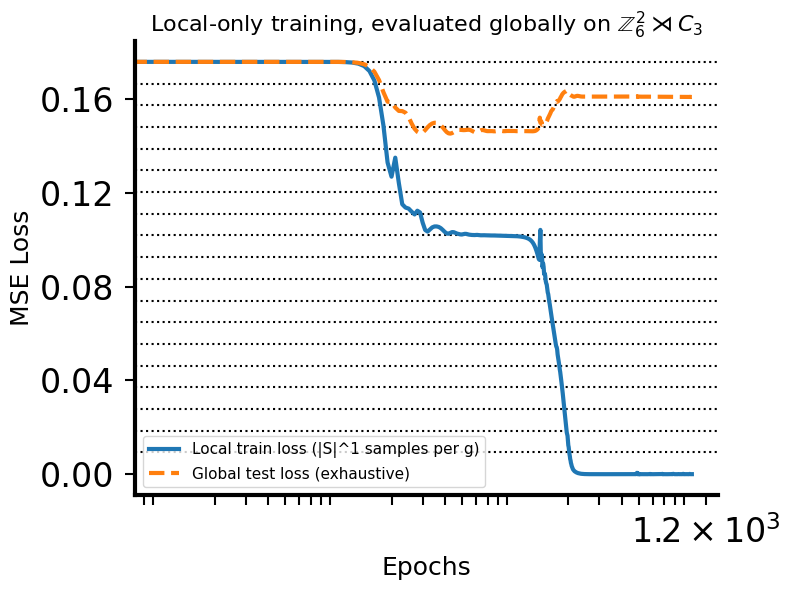

In [27]:
theory_levels = viz.loss_plateau_predictions(tpl, group)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(loss_history, lw=3, label=f"Local train loss (|S|^{seq_len - 1} samples per g)")
ax.plot(val_loss_history, lw=3, label=f"Global test loss ({eval_mode})", linestyle="--")

for level in theory_levels[:-1]:
    ax.axhline(y=level, color="black", linestyle=":", linewidth=1.5, zorder=-2)

ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlabel("Epochs", fontsize=18)
ax.set_ylabel("MSE Loss", fontsize=18)
ax.set_title(f"Local-only training, evaluated globally on {group_label_latex}", fontsize=16)
ax.legend(fontsize=11, loc="best")
viz.style_axes(ax)
ax.grid(False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_loss.pdf", bbox_inches="tight")
plt.show()

## Power Spectrum Over Training

Same diagnostic as in the global-trained RNN notebook: how the model's
output power in each irrep evolves. We feed the *global* eval inputs into the
model so the spectrum reflects what the model produces on arbitrary pairs,
not just on local ones.


Computing power at step 1 with output shape (233, 108)
Computing power at step 56 with output shape (233, 108)
Computing power at step 66 with output shape (233, 108)
Computing power at step 76 with output shape (233, 108)
Computing power at step 86 with output shape (233, 108)
Computing power at step 96 with output shape (233, 108)


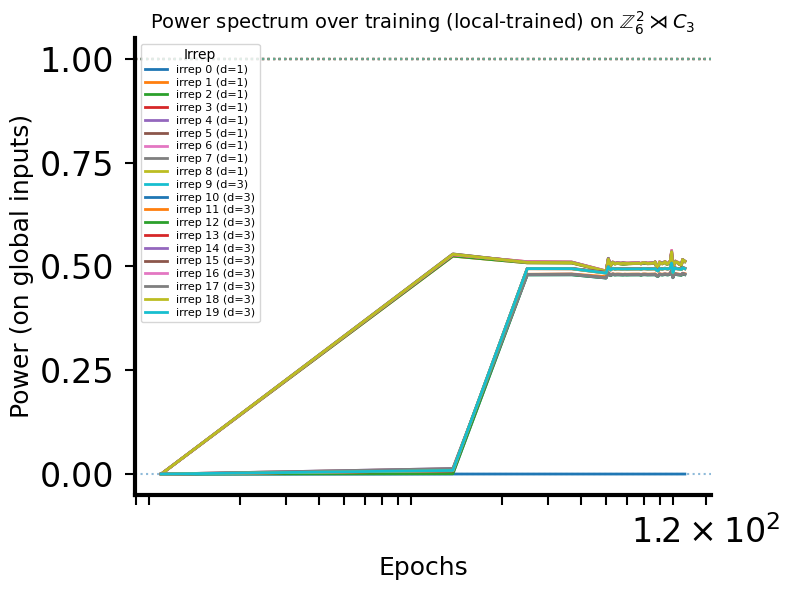

In [24]:
powers_over_time, power_steps = viz.model_power_over_time(
    group,
    model=net,
    param_history=param_history,
    model_inputs=X_global,
)

template_pwr = group.power_spectrum(tpl)
irreps = group.irreps()

tab_colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(8, 6))

for k_ in range(n_irreps):
    color = tab_colors[k_ % len(tab_colors)]
    ax.plot(power_steps, powers_over_time[:, k_], color=color, lw=2,
            label=f"irrep {k_} (d={irreps[k_].dim})")
    ax.axhline(template_pwr[k_], color=color, linestyle="dotted", linewidth=1.5,
               alpha=0.5, zorder=-10)

ax.set_xscale("log")
ax.set_ylabel("Power (on global inputs)", fontsize=18)
ax.set_xlabel("Epochs", fontsize=18)
ax.set_title(f"Power spectrum over training (local-trained) on {group_label_latex}", fontsize=14)
ax.legend(fontsize=8, title="Irrep", title_fontsize=10, loc="upper left", labelspacing=0.25)
viz.style_axes(ax)
ax.grid(False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_power_spectrum.pdf", bbox_inches="tight")
plt.show()

## Output Weights — Grid Overview


/tmp/ipykernel_2904573/1780053180.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


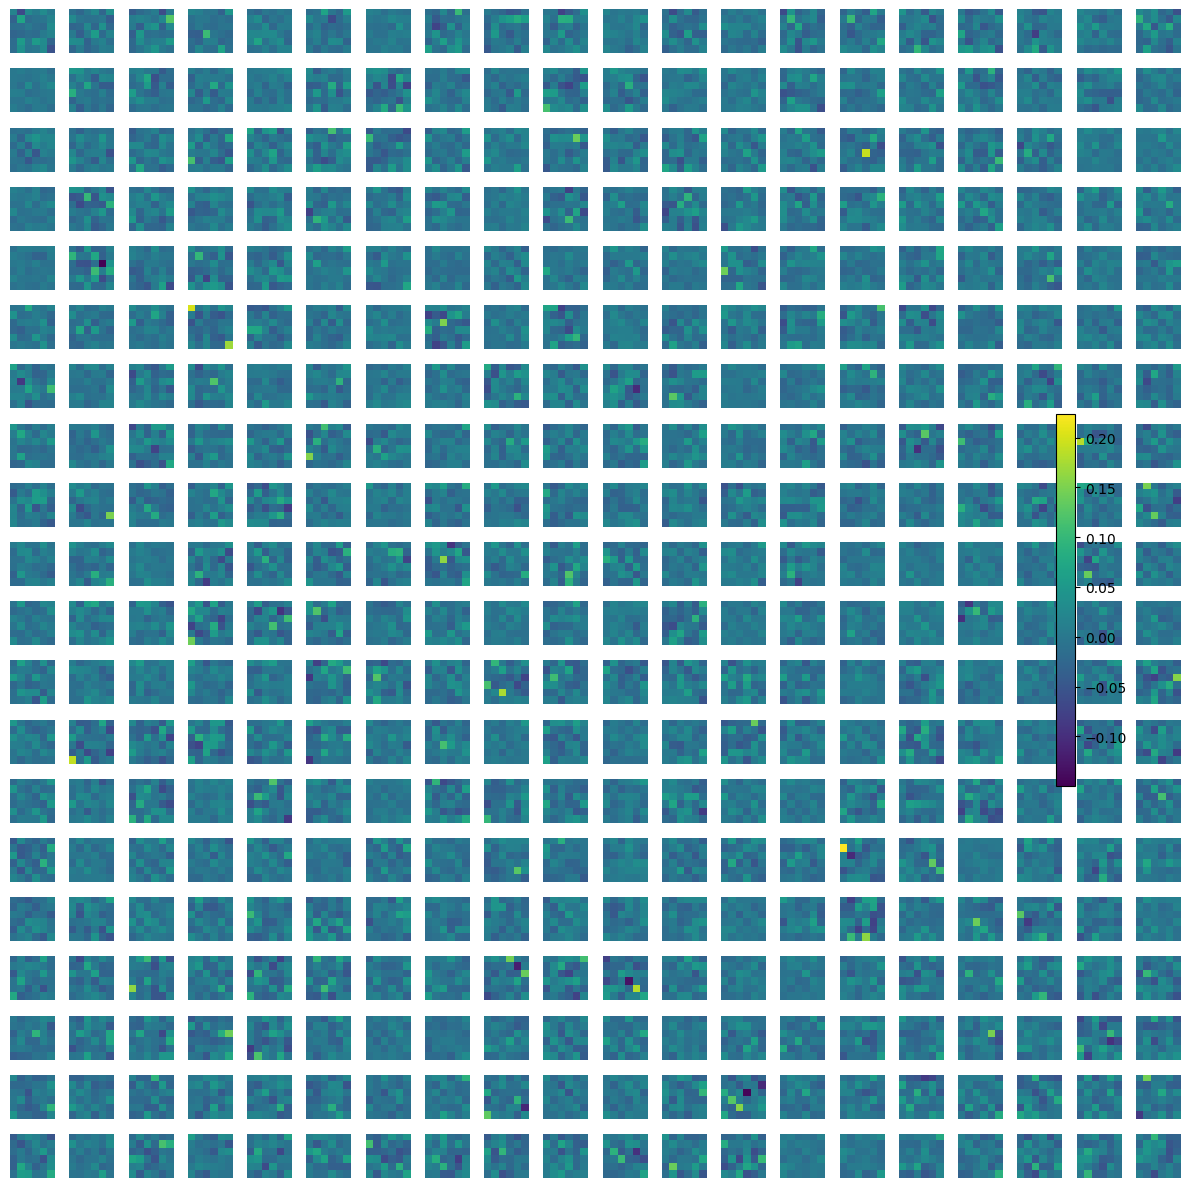

In [25]:
t = -1
param = "W_out"
rows, cols = 20, 20

W_all = param_history[t][param].detach().cpu().numpy()

images = []
for idx in range(min(rows * cols, W_all.shape[1])):
    w = W_all[:, idx]
    images.append(w.reshape(m, n, n).sum(axis=0))

vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)
norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = np.asarray(axes).reshape(rows, cols)
im = None
for k_, ax in enumerate(axes.flat):
    if k_ < len(images):
        im = ax.imshow(images[k_], cmap="viridis", norm=norm)
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_grid.pdf", bbox_inches="tight")
plt.show()


## Output Weights — Grouped by Dominant Irrep


In [26]:
W_all = param_history[-1][param].detach().cpu().numpy()
num_neurons = W_all.shape[1]

images = []
group_ids = []
for idx in range(num_neurons):
    w = W_all[:, idx]
    images.append(w.reshape(m, n, n).sum(axis=0))
    group_ids.append(int(np.argmax(group.power_spectrum(w))))

group_ids = np.array(group_ids)
unique_groups = np.unique(group_ids)
neurons_by_group = {
    gid: sorted(
        np.where(group_ids == gid)[0].tolist(),
        key=lambda idx: group.power_spectrum(W_all[:, idx])[gid],
        reverse=True,
    )
    for gid in unique_groups
}

irreps = group.irreps()
group_elements = group.elements()
irrep_images = []
irrep_dims = []
for irrep in irreps:
    mats = np.array([irrep(g) for g in group_elements])
    if mats.ndim == 1:
        mats = mats[:, None, None]
    d = mats.shape[1]
    irrep_dims.append(d)
    vals = mats.real.reshape(m, n, n, d, d)
    irrep_images.append(vals.sum(axis=0).sum(axis=(-1, -2)))

all_groups = list(range(len(irreps)))
max_neurons = max([len(neurons_by_group.get(gid, [])) for gid in all_groups] + [1])
ncols = 2 + max_neurons

fig, axes = plt.subplots(
    len(all_groups), ncols,
    figsize=(1.25 * ncols, 1.5 * len(all_groups)),
    squeeze=False,
    gridspec_kw={"width_ratios": [1.0, 0.22] + [1.0] * max_neurons},
)
cmap = "viridis"
for r, gid in enumerate(all_groups):
    neuron_list = neurons_by_group.get(gid, [])
    ax_theory = axes[r, 0]
    ax_theory.imshow(irrep_images[gid], cmap=cmap, origin="lower")
    ax_theory.set_xticks([]); ax_theory.set_yticks([])
    axes[r, 1].axis("off")
    for c in range(max_neurons):
        ax = axes[r, c + 2]
        if c < len(neuron_list):
            ax.imshow(images[neuron_list[c]], cmap=cmap, origin="lower")
            ax.set_title(f"h={neuron_list[c]}", fontsize=7)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.axis("off")
    ax_theory.set_ylabel(
        f"irrep {gid}\ndim={irrep_dims[gid]}\ncount={len(neuron_list)}",
        rotation=0, ha="right", va="center", labelpad=38, fontsize=10,
    )

fig.suptitle(f"{param}: theory irrep + empirical neurons (local-trained)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_by_irrep.pdf", bbox_inches="tight")
plt.show()
